In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

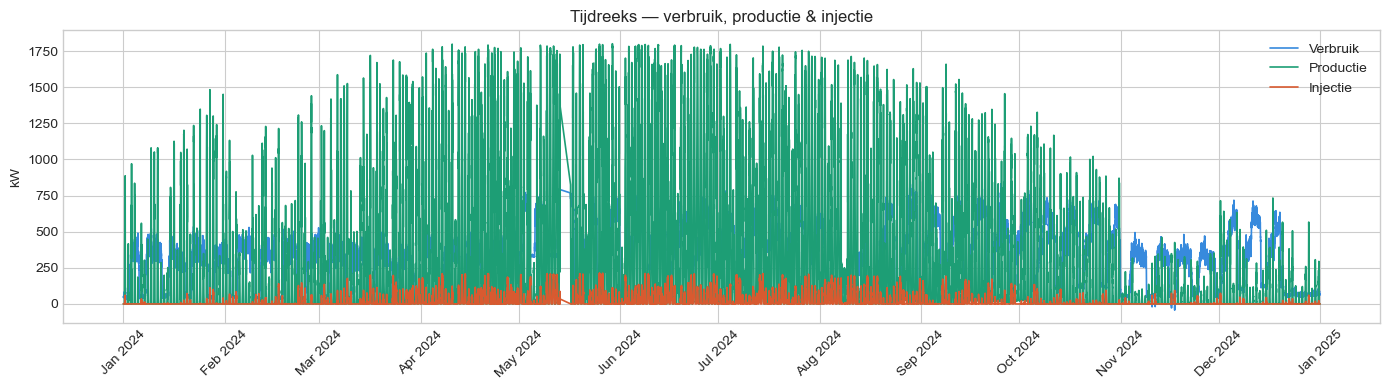

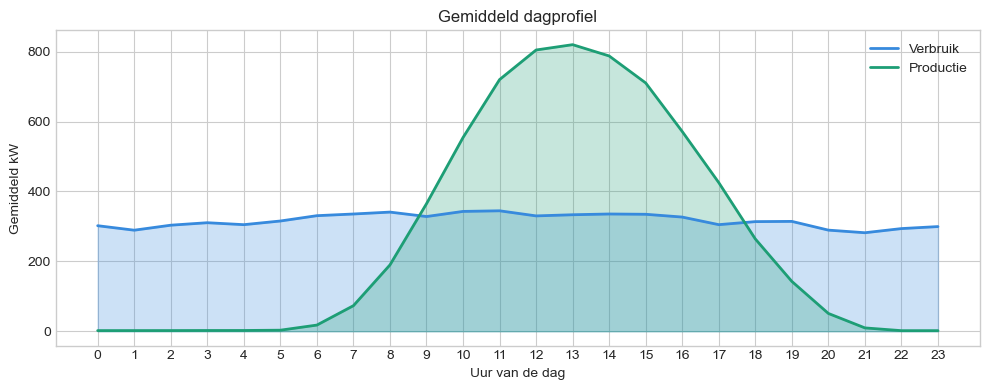

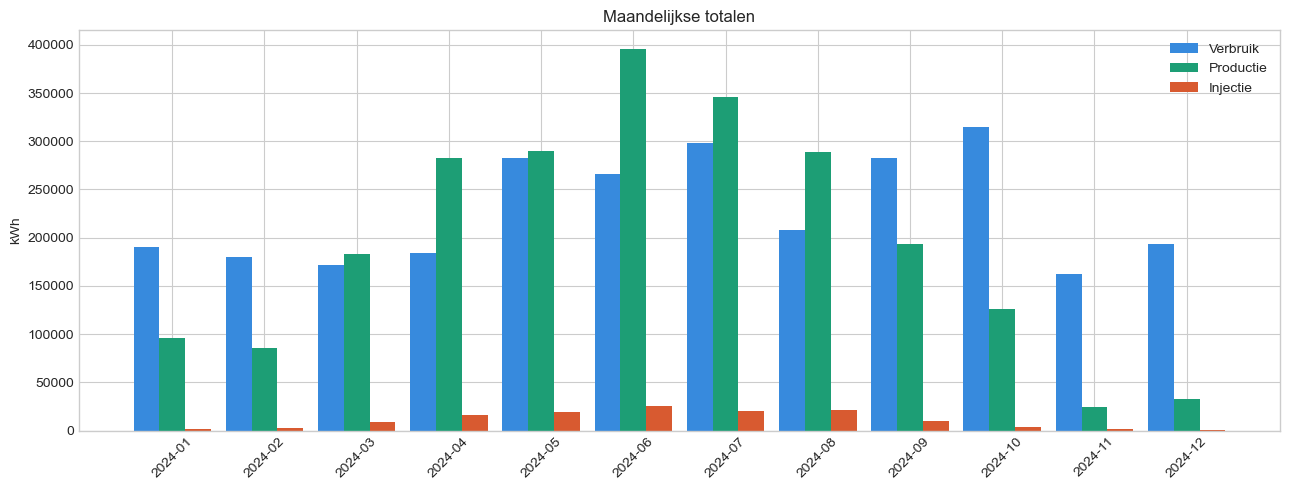

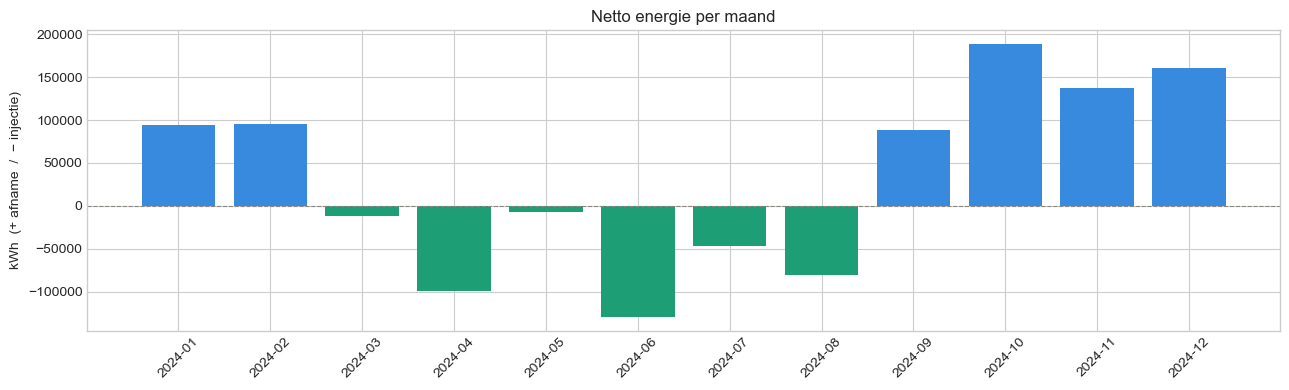

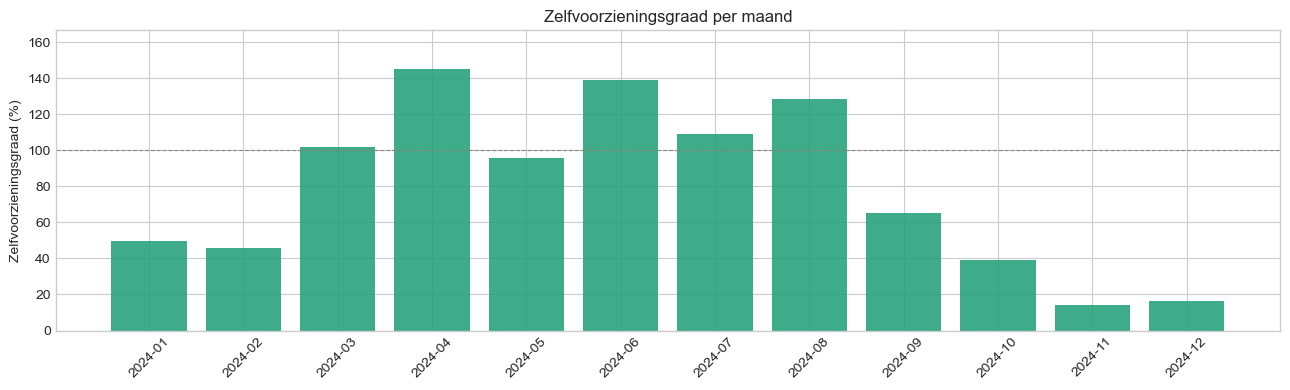

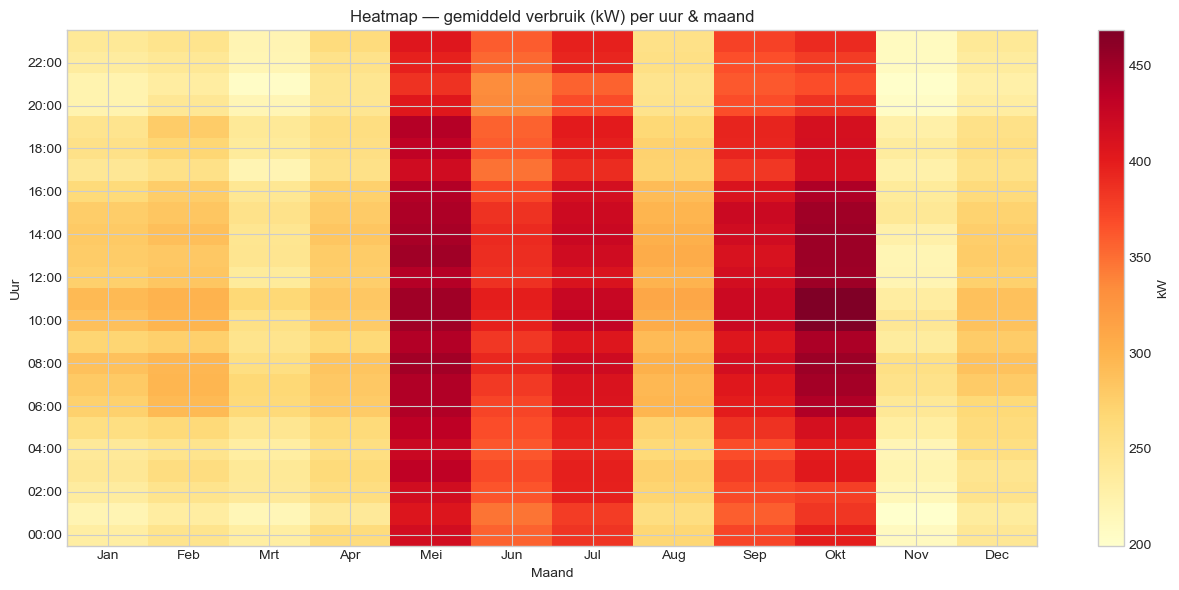

✓ Alle grafieken opgeslagen als PNG.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# ── Inladen ──────────────────────────────────────────────────────────────────
df = pd.read_excel('data/Data 2024/energiebeheer_2024.xlsx')         # pas aan naar jouw bestandsnaam

df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum").reset_index(drop=True)

# Afgeleide kolommen
df["Netto (kW)"] = df["Verbruik (kW)"] - df["Productie (kW)"]
df["Maand"]      = df["Datum"].dt.to_period("M")
df["Uur"]        = df["Datum"].dt.hour + df["Datum"].dt.minute / 60

# ── Stijl ─────────────────────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
BLAUW   = "#378ADD"
GROEN   = "#1D9E75"
ORANJE  = "#D85A30"
GRIJS   = "#888780"

# ═══════════════════════════════════════════════════════════════════════════════
# 1. TIJDREEKS — verbruik, productie en injectie
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["Datum"], df["Verbruik (kW)"],  color=BLAUW,  lw=1.2, label="Verbruik")
ax.plot(df["Datum"], df["Productie (kW)"], color=GROEN,  lw=1.2, label="Productie")
ax.plot(df["Datum"], df["Injectie (kW)"],  color=ORANJE, lw=1.2, label="Injectie")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
ax.set_ylabel("kW")
ax.set_title("Tijdreeks — verbruik, productie & injectie")
ax.legend()
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 2. GEMIDDELD DAGPROFIEL per uur
# ═══════════════════════════════════════════════════════════════════════════════
dagprofiel = df.groupby(df["Datum"].dt.hour)[
    ["Verbruik (kW)", "Productie (kW)"]
].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(dagprofiel.index, dagprofiel["Verbruik (kW)"],  alpha=0.25, color=BLAUW)
ax.fill_between(dagprofiel.index, dagprofiel["Productie (kW)"], alpha=0.25, color=GROEN)
ax.plot(dagprofiel.index, dagprofiel["Verbruik (kW)"],  color=BLAUW,  lw=2, label="Verbruik")
ax.plot(dagprofiel.index, dagprofiel["Productie (kW)"], color=GROEN,  lw=2, label="Productie")
ax.set_xticks(range(0, 24))
ax.set_xlabel("Uur van de dag")
ax.set_ylabel("Gemiddeld kW")
ax.set_title("Gemiddeld dagprofiel")
ax.legend()
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 3. MAANDELIJKSE TOTALEN (kWh)
# ═══════════════════════════════════════════════════════════════════════════════
# 15-minuten intervallen → delen door 4 geeft kWh
maand = df.groupby("Maand")[
    ["Verbruik (kW)", "Productie (kW)", "Injectie (kW)"]
].sum() / 4

maand.index = maand.index.astype(str)
x = np.arange(len(maand))
breedte = 0.28

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - breedte, maand["Verbruik (kW)"],  breedte, label="Verbruik",  color=BLAUW)
ax.bar(x,           maand["Productie (kW)"], breedte, label="Productie", color=GROEN)
ax.bar(x + breedte, maand["Injectie (kW)"],  breedte, label="Injectie",  color=ORANJE)
ax.set_xticks(x)
ax.set_xticklabels(maand.index, rotation=45)
ax.set_ylabel("kWh")
ax.set_title("Maandelijkse totalen")
ax.legend()
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 4. NETTO ENERGIE per maand (afname vs injectie)
# ═══════════════════════════════════════════════════════════════════════════════
maand_netto = df.groupby("Maand")["Netto (kW)"].sum() / 4
maand_netto.index = maand_netto.index.astype(str)

kleuren = [BLAUW if v >= 0 else GROEN for v in maand_netto]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(maand_netto.index, maand_netto, color=kleuren)
ax.axhline(0, color=GRIJS, lw=0.8, linestyle="--")
ax.set_ylabel("kWh  (+ afname  /  − injectie)")
ax.set_title("Netto energie per maand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 5. ZELFVOORZIENINGSGRAAD per maand (%)
# ═══════════════════════════════════════════════════════════════════════════════
maand_v = df.groupby("Maand")["Verbruik (kW)"].sum()
maand_p = df.groupby("Maand")["Productie (kW)"].sum()

# Zelfverbruik = productie die niet geïnjecteerd wordt
maand_i = df.groupby("Maand")["Injectie (kW)"].sum()
zelfverbruik = (maand_p - maand_i).clip(lower=0)
zvg = (zelfverbruik / maand_v * 100).fillna(0)
zvg.index = zvg.index.astype(str)

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(zvg.index, zvg, color=GROEN, alpha=0.85)
ax.axhline(100, color=GRIJS, lw=0.8, linestyle="--", label="100%")
ax.set_ylabel("Zelfvoorzieningsgraad (%)")
ax.set_title("Zelfvoorzieningsgraad per maand")
ax.set_ylim(0, max(zvg.max() * 1.15, 10))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 6. HEATMAP — gemiddeld uurverbruik per maand
# ═══════════════════════════════════════════════════════════════════════════════
df["Maand_nr"] = df["Datum"].dt.month
df["Uur_nr"]   = df["Datum"].dt.hour

pivot = df.pivot_table(
    values="Verbruik (kW)",
    index="Uur_nr",
    columns="Maand_nr",
    aggfunc="mean"
)

maand_namen = ["Jan","Feb","Mrt","Apr","Mei","Jun","Jul","Aug","Sep","Okt","Nov","Dec"]
pivot.columns = [maand_namen[m - 1] for m in pivot.columns]

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(pivot, aspect="auto", cmap="YlOrRd", origin="lower")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(0, 24, 2))
ax.set_yticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])
ax.set_xlabel("Maand")
ax.set_ylabel("Uur")
ax.set_title("Heatmap — gemiddeld verbruik (kW) per uur & maand")
plt.colorbar(im, ax=ax, label="kW")
plt.tight_layout()
plt.show()

print("✓ Alle grafieken opgeslagen als PNG.")

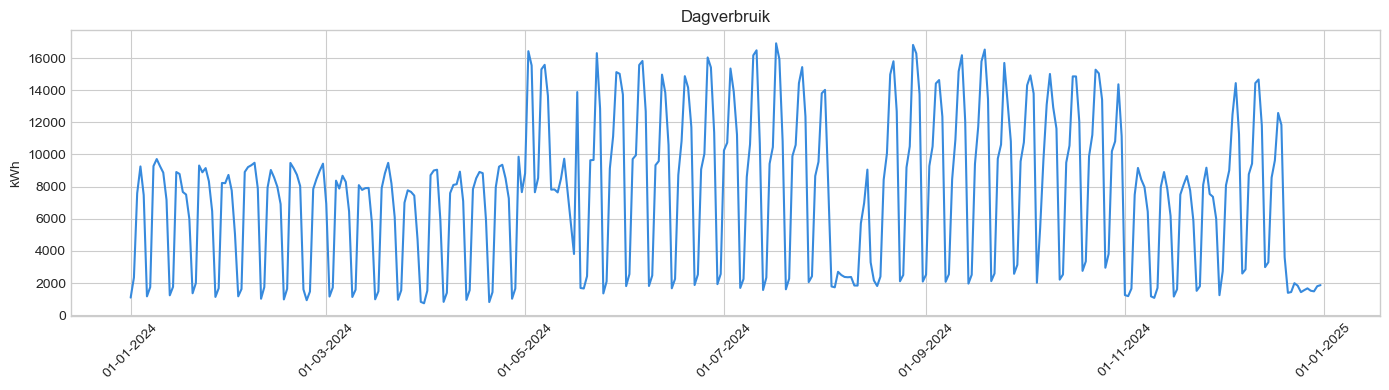

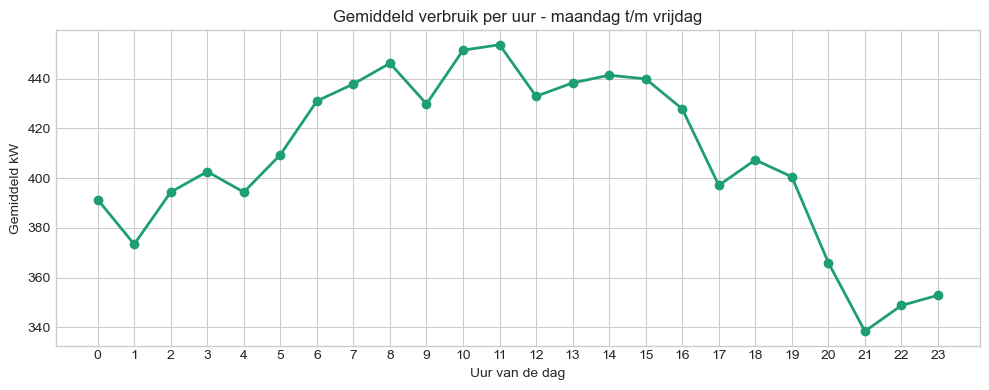

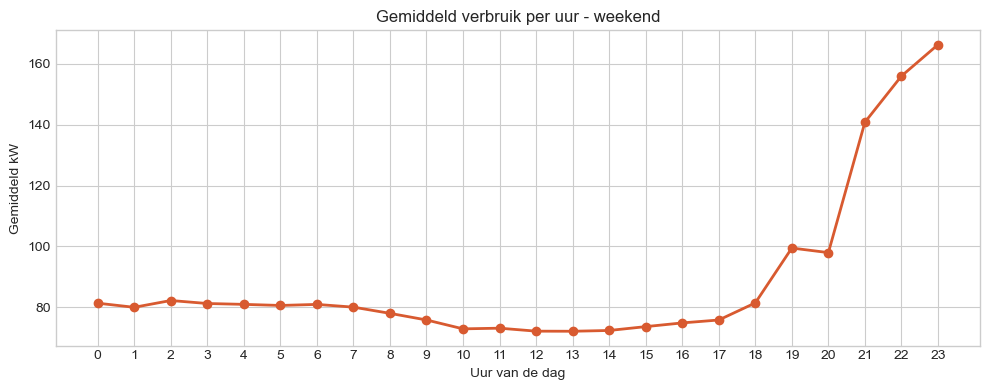

In [ ]:
# Nieuwe verbruiksgrafieken op basis van cell 2
# - dagverbruik per kalenderdag
# - gemiddeld verbruik per uur op werkdagen
# - gemiddeld verbruik per uur in het weekend

df["Datum"] = pd.to_datetime(df["Datum"])
df["Dag"] = df["Datum"].dt.normalize()
df["Dagtype"] = np.where(df["Datum"].dt.dayofweek < 5, "Maandag-vrijdag", "Weekend")

# 1. Verbruik per dag
verbruik_per_dag = df.groupby("Dag")["Verbruik (kW)"].sum() / 4

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(verbruik_per_dag.index, verbruik_per_dag.values, color=BLAUW, lw=1.5)
ax.set_title("Dagverbruik")
ax.set_ylabel("kWh")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Gemiddeld verbruik per uur op maandag t/m vrijdag
verbruik_werkdagen = df[df["Dagtype"] == "Maandag-vrijdag"].groupby(df["Datum"].dt.hour)["Verbruik (kW)"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(verbruik_werkdagen.index, verbruik_werkdagen.values, color=GROEN, lw=2, marker="o")
ax.set_xticks(range(0, 24))
ax.set_xlabel("Uur van de dag")
ax.set_ylabel("Gemiddeld kW")
ax.set_title("Gemiddeld verbruik per uur - maandag t/m vrijdag")
plt.tight_layout()
plt.show()

# 3. Gemiddeld verbruik per uur in het weekend
verbruik_weekend = df[df["Dagtype"] == "Weekend"].groupby(df["Datum"].dt.hour)["Verbruik (kW)"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(verbruik_weekend.index, verbruik_weekend.values, color=ORANJE, lw=2, marker="o")
ax.set_xticks(range(0, 24))
ax.set_xlabel("Uur van de dag")
ax.set_ylabel("Gemiddeld kW")
ax.set_title("Gemiddeld verbruik per uur - weekend")
plt.tight_layout()
plt.show()


September samenvatting
Aantal meetpunten: 2879
Verbruik:   282619.8 kWh
Productie:  193612.9 kWh
Injectie:   9961.6 kWh
Netto:      89006.9 kWh


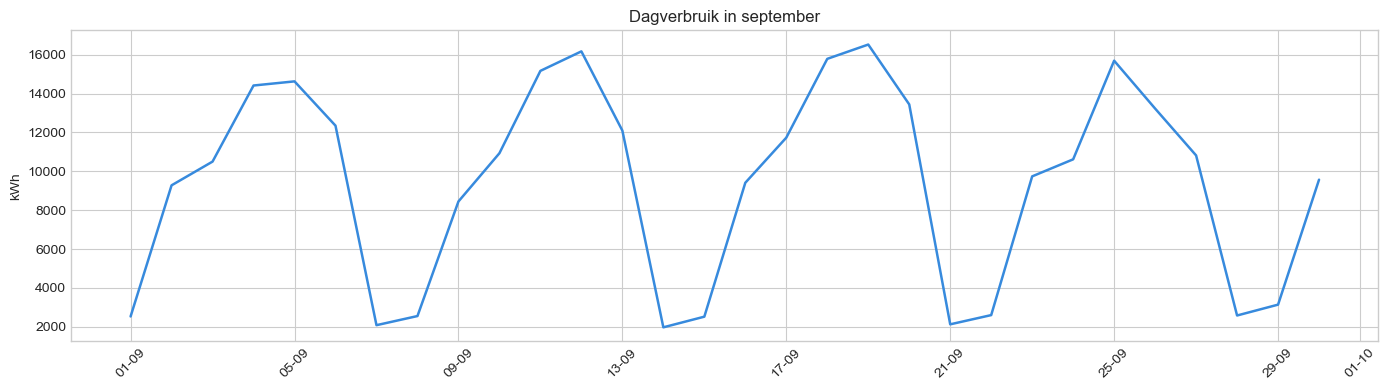

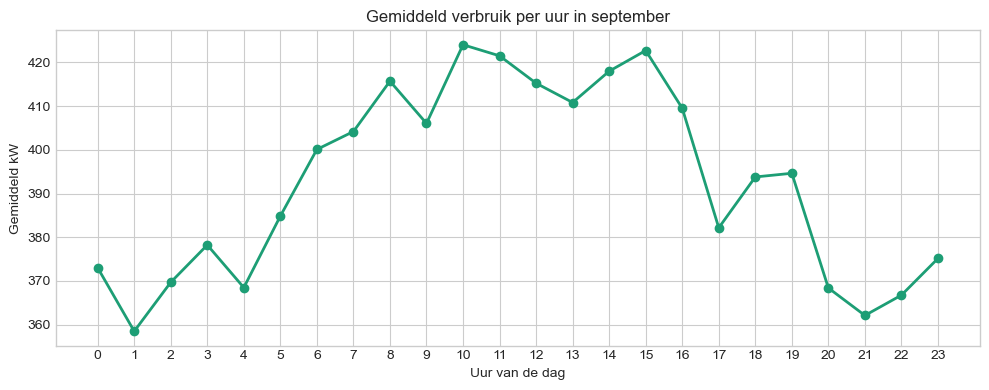

In [15]:
# Analyse van september
sep_df = df[df["Datum"].dt.month == 9].copy()

if sep_df.empty:
    print("Geen data gevonden voor september.")
else:
    sep_df["Dag"] = sep_df["Datum"].dt.normalize()
    sep_df["Uur"] = sep_df["Datum"].dt.hour
    sep_df["Netto (kW)"] = sep_df["Verbruik (kW)"] - sep_df["Productie (kW)"]

    sep_verbruik_kwh = sep_df["Verbruik (kW)"].sum() / 4
    sep_productie_kwh = sep_df["Productie (kW)"].sum() / 4
    sep_injectie_kwh = sep_df["Injectie (kW)"].sum() / 4
    sep_netto_kwh = sep_df["Netto (kW)"].sum() / 4

    print("September samenvatting")
    print(f"Aantal meetpunten: {len(sep_df)}")
    print(f"Verbruik:   {sep_verbruik_kwh:.1f} kWh")
    print(f"Productie:  {sep_productie_kwh:.1f} kWh")
    print(f"Injectie:   {sep_injectie_kwh:.1f} kWh")
    print(f"Netto:      {sep_netto_kwh:.1f} kWh")

    # 1. Dagverbruik in september
    sep_dag = sep_df.groupby("Dag")["Verbruik (kW)"].sum() / 4

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(sep_dag.index, sep_dag.values, color=BLAUW, lw=1.8)
    ax.set_title("Dagverbruik in september")
    ax.set_ylabel("kWh")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 2. Gemiddeld uurprofiel in september
    sep_uur = sep_df.groupby("Uur")["Verbruik (kW)"].mean()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(sep_uur.index, sep_uur.values, color=GROEN, lw=2, marker="o")
    ax.set_xticks(range(0, 24))
    ax.set_xlabel("Uur van de dag")
    ax.set_ylabel("Gemiddeld kW")
    ax.set_title("Gemiddeld verbruik per uur in september")
    plt.tight_layout()
    plt.show()


Weekdag totaalverbruik in september
Weekdag
Maandag      46442.0
Dinsdag      43778.1
Woensdag     61067.5
Donderdag    60556.1
Vrijdag      48704.0
Zaterdag      8746.3
Zondag       13325.8
Name: Verbruik (kW), dtype: float64
Meest verbruikte weekdag: Woensdag (61067.5 kWh)


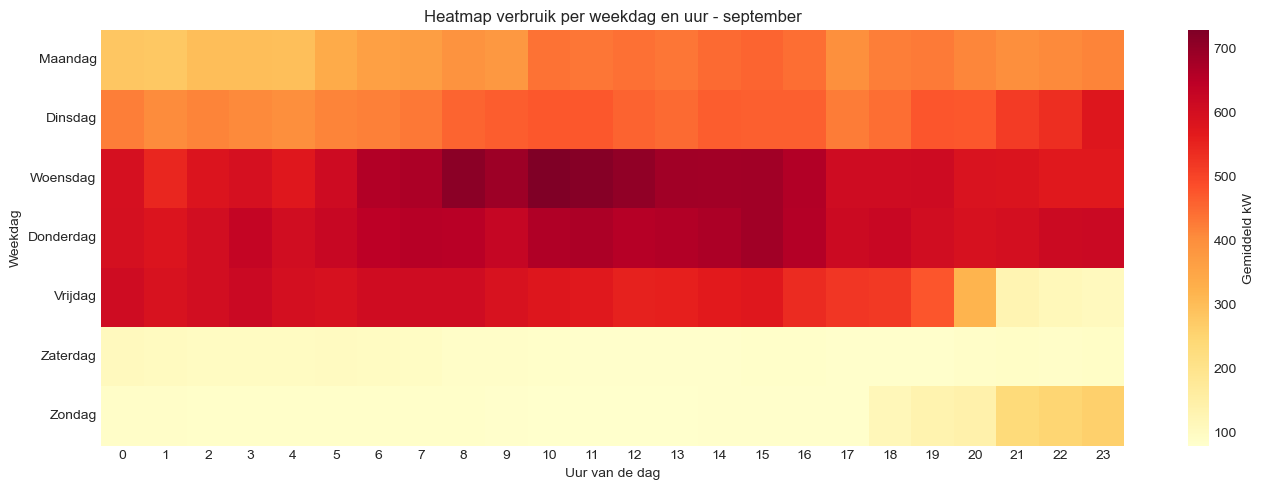

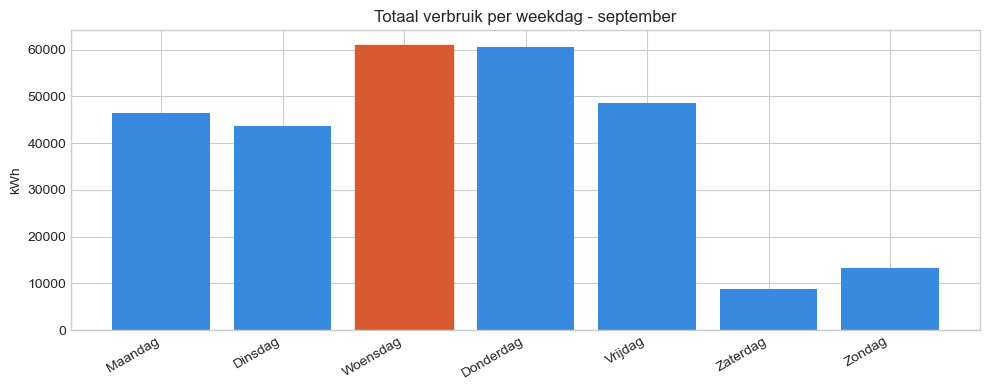

In [17]:
# Weekdag-analyse voor september
if sep_df.empty:
    print("Geen data gevonden voor september, dus geen weekdag-analyse mogelijk.")
else:
    weekday_order = ["Maandag", "Dinsdag", "Woensdag", "Donderdag", "Vrijdag", "Zaterdag", "Zondag"]
    weekday_map = {0: "Maandag", 1: "Dinsdag", 2: "Woensdag", 3: "Donderdag", 4: "Vrijdag", 5: "Zaterdag", 6: "Zondag"}

    sep_df["Weekdag"] = sep_df["Datum"].dt.dayofweek.map(weekday_map)

    weekday_totals = (sep_df.groupby("Weekdag")["Verbruik (kW)"].sum() / 4).reindex(weekday_order)
    meest_verbruikte_weekdag = weekday_totals.idxmax()

    print("Weekdag totaalverbruik in september")
    print(weekday_totals.round(1))
    print(f"Meest verbruikte weekdag: {meest_verbruikte_weekdag} ({weekday_totals.max():.1f} kWh)")

    heatmap_data = sep_df.pivot_table(
        index="Weekdag",
        columns="Uur",
        values="Verbruik (kW)",
        aggfunc="mean"
    ).reindex(weekday_order)

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.heatmap(
        heatmap_data,
        cmap="YlOrRd",
        ax=ax,
        cbar_kws={"label": "Gemiddeld kW"}
    )
    ax.set_title("Heatmap verbruik per weekdag en uur - september")
    ax.set_xlabel("Uur van de dag")
    ax.set_ylabel("Weekdag")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(weekday_totals.index, weekday_totals.values, color=BLAUW)
    bars[weekday_totals.index.get_loc(meest_verbruikte_weekdag)].set_color(ORANJE)
    ax.set_ylabel("kWh")
    ax.set_title("Totaal verbruik per weekdag - september")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


In [4]:
df.head()

,Datum,Verbruik (kW),Productie (kW),Injectie (kW),Netto (kW),Maand,Uur,Maand_nr,Uur_nr
0,2024-01-01 00:15:00,49.457740,0.0,0.0,49.457740,2024-01,0.25,1,0
1,2024-01-01 00:30:00,49.457740,0.0,0.0,49.457740,2024-01,0.50,1,0
2,2024-01-01 00:45:00,49.457740,0.0,0.0,49.457740,2024-01,0.75,1,0
3,2024-01-01 01:00:00,49.457740,0.0,0.0,49.457740,2024-01,1.00,1,1
4,2024-01-01 01:15:00,48.142436,0.0,0.0,48.142436,2024-01,1.25,1,1


In [3]:
#Als producctie negatief is naar 0 
df_2024 = pd.read_excel('data/Data 2024/energiebeheer_2024.xlsx')

df_2024.head(50)


,Datum,Verbruik (kW),Productie (kW),Injectie (kW)
0,2024-01-01 00:15:00,49.457740,0.000000,0.000000
1,2024-01-01 00:30:00,49.457740,0.000000,0.000000
2,2024-01-01 00:45:00,49.457740,0.000000,0.000000
3,2024-01-01 01:00:00,49.457740,0.000000,0.000000
4,2024-01-01 01:15:00,48.142436,0.000000,0.000000
5,2024-01-01 01:30:00,48.975484,0.000000,0.000000
6,2024-01-01 01:45:00,45.374172,0.000000,0.000000
7,2024-01-01 02:00:00,45.772472,0.000000,0.000000
8,2024-01-01 02:15:00,46.029052,0.000000,0.000000
9,2024-01-01 02:30:00,45.801864,0.000000,0.000000


In [6]:
df_2024['Totaalverbruik'] = (df_2024['Verbruik (kW)'] + df_2024['Productie (kW)'] - df_2024['Injectie (kW)']).clip(lower=0)


In [7]:
df_2024['Verbruik_pu'] = df_2024['Totaalverbruik'] / df_2024['Totaalverbruik'].sum()
df_2024['Productie_pu'] = df_2024['Productie (kW)'] / df_2024['Productie (kW)'].sum()

In [8]:
# Eigen verbruik PU
df_2024["Verschil"] = df_2024["Productie_pu"] - df_2024["Verbruik_pu"]

df_2024.head()

,Datum,Verbruik (kW),Productie (kW),Injectie (kW),Totaalverbruik,Verbruik_pu,Productie_pu,Verschil
0,2024-01-01 00:15:00,49.457740,0.0,0.0,49.457740,0.000002,0.0,-0.000002
1,2024-01-01 00:30:00,49.457740,0.0,0.0,49.457740,0.000002,0.0,-0.000002
2,2024-01-01 00:45:00,49.457740,0.0,0.0,49.457740,0.000002,0.0,-0.000002
3,2024-01-01 01:00:00,49.457740,0.0,0.0,49.457740,0.000002,0.0,-0.000002
4,2024-01-01 01:15:00,48.142436,0.0,0.0,48.142436,0.000002,0.0,-0.000002


In [9]:
df_2024['Eigenverbruik'] = np.where(df_2024['Verschil'] < 0, 
                                   df_2024['Productie_pu'], 
                                   df_2024['Verbruik_pu'])

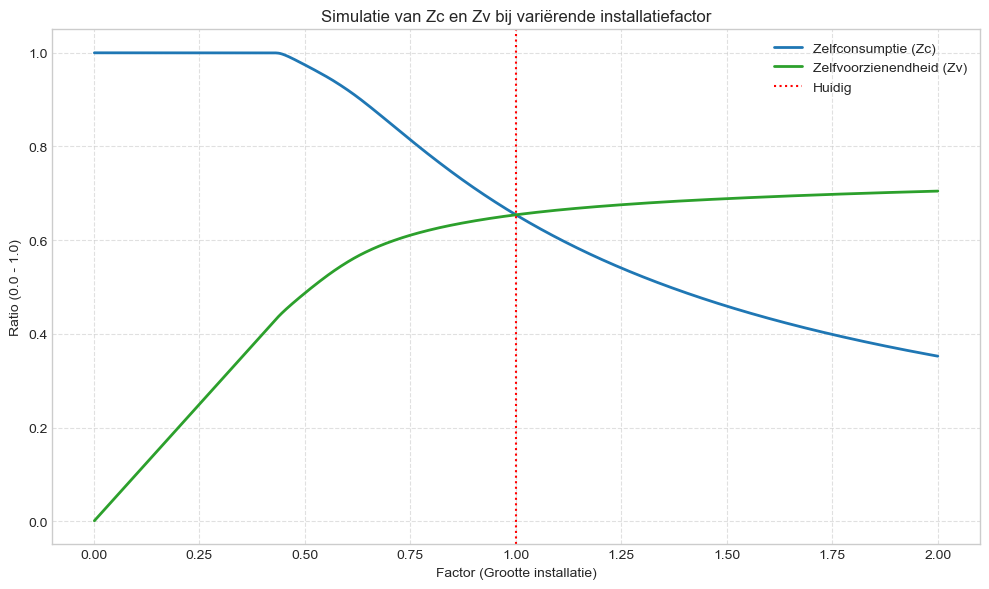

Bij factor 1.0: Zc = 65.42%, Zv = 65.42%


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Instellingen
factors = np.arange(0.001, 2.001, 0.001)

def bereken_simulatie(df, factors):
    zc_list = []
    zv_list = []
    total_verbruik = df['Verbruik_pu'].sum()
    
    for f in factors:
        sim_prod = df['Productie_pu'] * f
        # Eigenverbruik is het minimum van verbruik en gesimuleerde productie
        eigenverbruik = np.minimum(df['Verbruik_pu'], sim_prod)
        
        sum_ev = eigenverbruik.sum()
        sum_prod = sim_prod.sum()
        
        zc = sum_ev / sum_prod if sum_prod > 0 else 0
        zv = sum_ev / total_verbruik if total_verbruik > 0 else 0
        
        zc_list.append(zc)
        zv_list.append(zv)
    return zc_list, zv_list

zc, zv = bereken_simulatie(df_2024, factors)

plt.figure(figsize=(10, 6))

plt.plot(factors, zc, label='Zelfconsumptie (Zc)', color='#1f77b4', linewidth=2)
plt.plot(factors, zv, label='Zelfvoorzienendheid (Zv)', color='#2ca02c', linewidth=2)

plt.title('Simulatie van Zc en Zv bij variërende installatiefactor')
plt.xlabel('Factor (Grootte installatie)')
plt.ylabel('Ratio (0.0 - 1.0)')

plt.axvline(x=1.0, color='red', linestyle=':', label='Huidig')

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

#print de laatste waarden van zc en zv bij factor 1.0 en zet in procenten
index_1 = np.where(factors == 1.0)[0][0]
print(f"Bij factor 1.0: Zc = {zc[index_1]*100:.2f}%, Zv = {zv[index_1]*100:.2f}%")

Analyse voor 2023:
Aantal punten in eigenverbruik: 2000
Aantal punten in 1e afgeleide: 1999
Aantal punten in 2e afgeleide: 1998

Zone grenzen:
🟢 Groene zone (ideaal): factor 0.00 - 0.45
🟡 Gele zone (kan nog): factor 0.45 - 0.80
🔴 Rode zone (weinig winst): factor 0.80 - 2.00


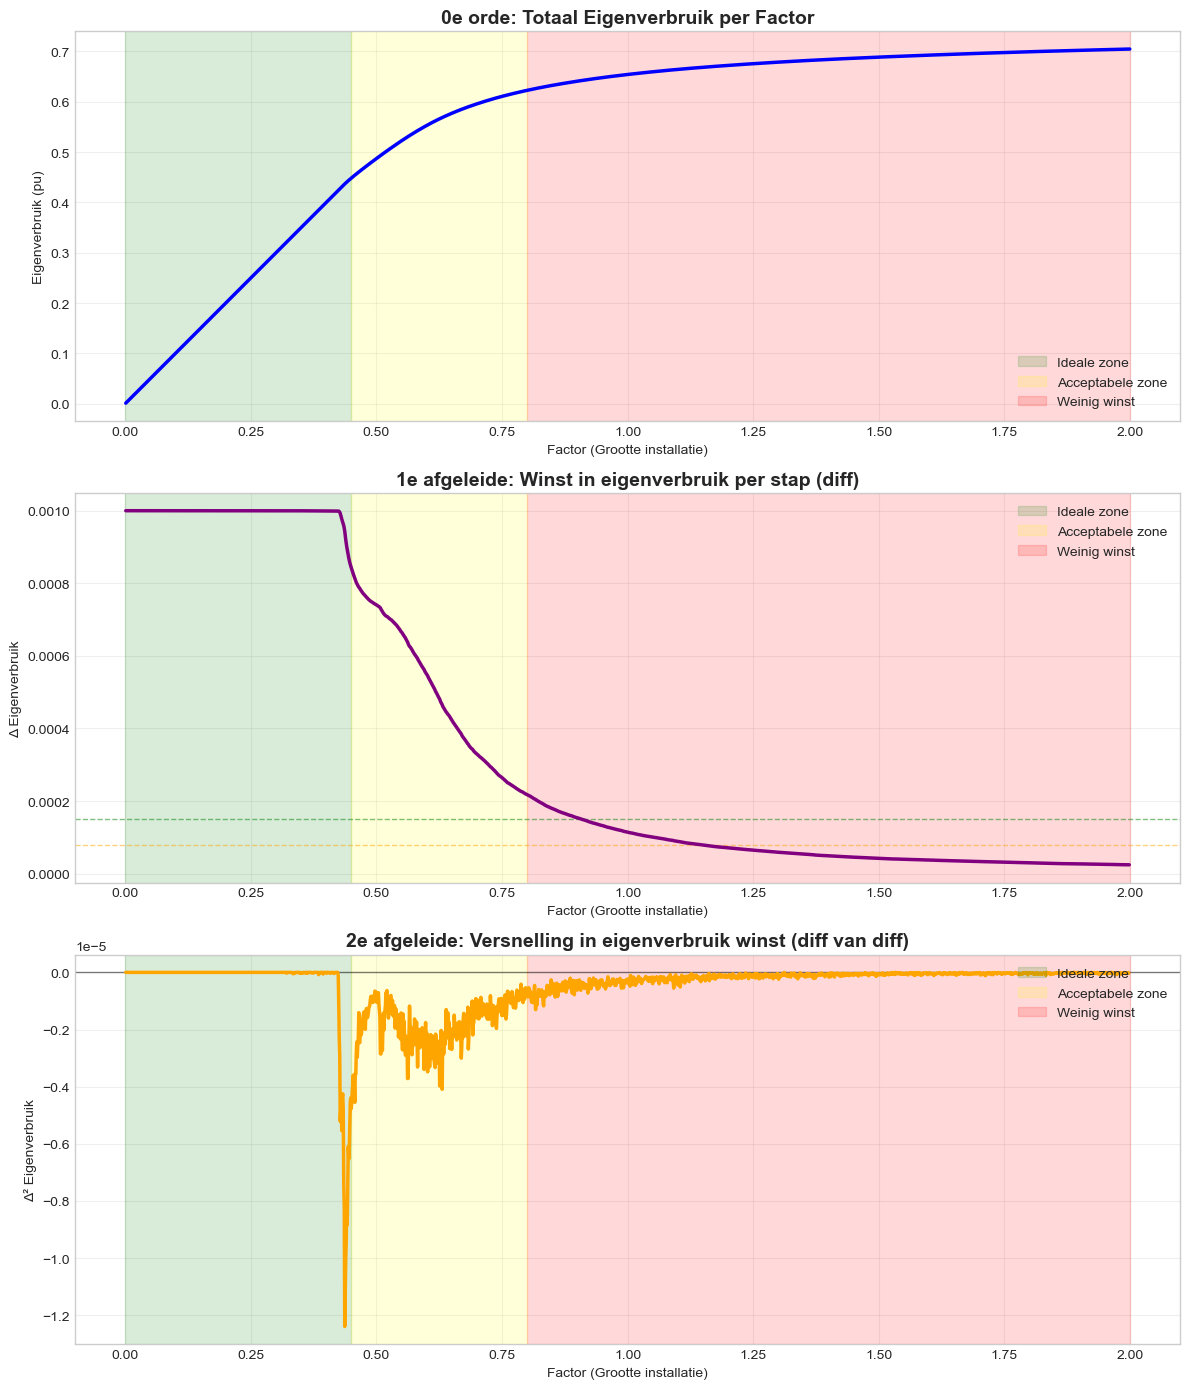

In [11]:
# --- Analyse met diff op Eigenverbruik: 0e, 1e en 2e afgeleide met zones ---

def bereken_eigenverbruik_en_afgeleiden(df, factors):
    """
    Berekent eigenverbruik en de 1e en 2e afgeleide met np.diff()
    """
    eigenverbruik_list = []
    
    # Bereken eigenverbruik voor elke factor
    for f in factors:
        sim_prod = df['Productie_pu'] * f
        eigenverbruik = np.minimum(df['Verbruik_pu'], sim_prod)
        eigenverbruik_list.append(eigenverbruik.sum())
    
    # Eerste afgeleide: hoeveel extra eigenverbruik per stap
    diff_1 = np.diff(eigenverbruik_list)
    
    # Tweede afgeleide: verandering in de winst per stap
    diff_2 = np.diff(diff_1)
    
    return eigenverbruik_list, diff_1, diff_2

# Bereken voor 2023
ev_list, diff_1, diff_2 = bereken_eigenverbruik_en_afgeleiden(df_2024, factors)

# Definieer zones op basis van 1e afgeleide
# Vind waar de 1e afgeleide onder bepaalde drempels komt
factors_diff1 = factors[:-1]

# Drempels voor zones
drempel_groen_geel = 0.00015  # Grens tussen groen en geel
drempel_geel_rood = 0.00008   # Grens tussen geel en rood

# Vind de factor-waarden voor zone grenzen
idx_groen_geel = np.where(diff_1 < drempel_groen_geel)[0]
idx_geel_rood = np.where(diff_1 < drempel_geel_rood)[0]

# Stel zones in op basis van gebruikervoorkeur
grens_groen_geel = 0.45  # Grens tussen groen en geel (gewijzigd)
grens_geel_rood = 0.80   # Grens tussen geel en rood (gewijzigd)

print(f"Analyse voor 2023:")
print(f"Aantal punten in eigenverbruik: {len(ev_list)}")
print(f"Aantal punten in 1e afgeleide: {len(diff_1)}")
print(f"Aantal punten in 2e afgeleide: {len(diff_2)}")
print(f"\nZone grenzen:")
print(f"🟢 Groene zone (ideaal): factor 0.00 - {grens_groen_geel:.2f}")
print(f"🟡 Gele zone (kan nog): factor {grens_groen_geel:.2f} - {grens_geel_rood:.2f}")
print(f"🔴 Rode zone (weinig winst): factor {grens_geel_rood:.2f} - {factors[-1]:.2f}")

# Visualiseer de drie plots met gekleurde zones
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 14))

# Functie om zones toe te voegen aan elke plot
def voeg_zones_toe(ax, y_min, y_max):
    ax.axvspan(0, grens_groen_geel, alpha=0.15, color='green', label='Ideale zone')
    ax.axvspan(grens_groen_geel, grens_geel_rood, alpha=0.15, color='yellow', label='Acceptabele zone')
    ax.axvspan(grens_geel_rood, factors[-1], alpha=0.15, color='red', label='Weinig winst')

# Plot 1: Eigenverbruik vs Factor
voeg_zones_toe(ax1, 0, max(ev_list))
ax1.plot(factors, ev_list, color='blue', linewidth=2.5, zorder=3)
ax1.set_title('0e orde: Totaal Eigenverbruik per Factor', fontsize=14, fontweight='bold')
ax1.set_xlabel('Factor (Grootte installatie)')
ax1.set_ylabel('Eigenverbruik (pu)')
ax1.grid(True, alpha=0.3, zorder=1)
ax1.legend(loc='lower right')

# Plot 2: Eerste afgeleide (diff)
voeg_zones_toe(ax2, min(diff_1), max(diff_1))
ax2.plot(factors_diff1, diff_1, color='purple', linewidth=2.5, zorder=3)
ax2.axhline(y=drempel_groen_geel, color='green', linestyle='--', alpha=0.5, linewidth=1)
ax2.axhline(y=drempel_geel_rood, color='orange', linestyle='--', alpha=0.5, linewidth=1)
ax2.set_title('1e afgeleide: Winst in eigenverbruik per stap (diff)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Factor (Grootte installatie)')
ax2.set_ylabel('Δ Eigenverbruik')
ax2.grid(True, alpha=0.3, zorder=1)
ax2.legend(loc='upper right')

# Plot 3: Tweede afgeleide (diff van diff)
factors_diff2 = factors[:-2]  # tweede diff heeft 2 elementen minder
voeg_zones_toe(ax3, min(diff_2), max(diff_2))
ax3.plot(factors_diff2, diff_2, color='orange', linewidth=2.5, zorder=3)
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
ax3.set_title('2e afgeleide: Versnelling in eigenverbruik winst (diff van diff)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Factor (Grootte installatie)')
ax3.set_ylabel('Δ² Eigenverbruik')
ax3.grid(True, alpha=0.3, zorder=1)
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()


--- Scenario en uitgangspunten ---
Scenario: Huidig scenario (gemeten opbrengst + totaalverbruik 2023)
Installatiefactor: 1.000
Jaarverbruik: 0.0 kWh = 0.000 MWh
Jaarproductie: 0.0 kWh
Sweep: 0 -> 2 kWh/MWh, stap 0.001 (2001 punten)
Cycli-limiet op basis van batterijkeuze: 500.0 cycli/jaar


,ratio_kWh_per_MWh,battery_nominal_kWh,Z_c,Z_v,equivalent_cycles_per_year,cycles_ok
0,0.0,0.000000e+00,0.986342,0.467378,0.000000e+00,True
500,0.5,2.747773e-09,0.986342,0.467378,5.228909e-09,True
1000,1.0,5.495545e-09,0.986342,0.467378,5.228909e-09,True
1500,1.5,8.243318e-09,0.986342,0.467378,5.228909e-09,True
2000,2.0,1.099109e-08,0.986342,0.467378,5.228909e-09,True


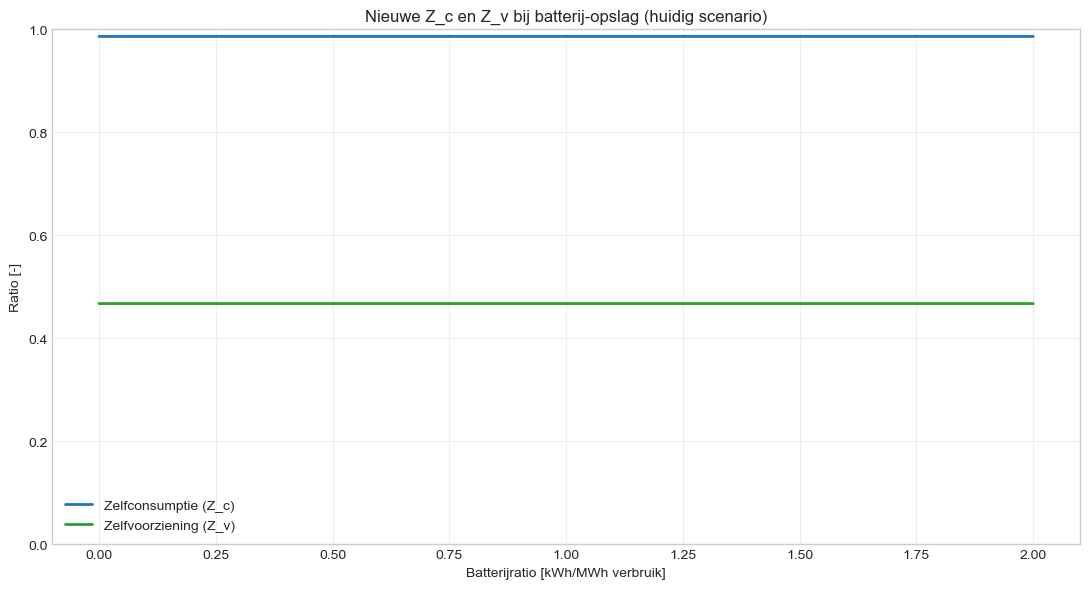

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --- 0) Scenario kiezen en inputdata uit huidige dataset ---
scenario_naam = "Huidig scenario (gemeten opbrengst + totaalverbruik 2023)"
installatie_factor = 1.0  # 1 specifiek gedimensioneerde installatie

df_s = df_2024.copy()

if "date" in df_s.columns:
    df_s["date"] = pd.to_datetime(df_s["date"])
    df_s = df_s.sort_values("date").set_index("date")
elif not isinstance(df_s.index, pd.DatetimeIndex):
    df_s.index = pd.to_datetime(df_s.index)
    df_s = df_s.sort_index()

# Totaalverbruik is al beschikbaar in je dataset (reeds berekend)

# Tijdstap in uren
stap_uur = df_s.index.to_series().diff().dt.total_seconds().dropna().median() / 3600
if pd.isna(stap_uur) or stap_uur <= 0:
    raise ValueError("Kon geen geldige tijdstap (uur) bepalen uit de datetime-index.")

# Energieprofielen (kWh per stap)
load_kwh = df_s["Totaalverbruik"].clip(lower=0).to_numpy() * stap_uur
prod_kwh = (df_s["Productie (kW)"].clip(lower=0).to_numpy() * installatie_factor) * stap_uur

jaarverbruik_kwh = float(load_kwh.sum())
jaarverbruik_mwh = jaarverbruik_kwh / 1000.0  # expliciet kWh -> MWh (factor 1000)
jaarproductie_kwh = float(prod_kwh.sum())

# --- 1) Batterijbank (pas aan naar de gekozen batterijbank) ---
batterij = {
    "dod": 0.90,
    "eta_charge": 0.96,
    "eta_discharge": 0.96,
    "self_discharge_per_day": 0.0005,
    "c_rate_charge": 0.5,
    "c_rate_discharge": 0.5,
    "v_nominal_v": 51.2,
    "max_charge_current_a": 200.0,
    "cycle_life_total": 6000,
    "target_lifetime_years": 12
}

max_cycles_per_year = batterij["cycle_life_total"] / batterij["target_lifetime_years"]
zelfontlading_stap = batterij["self_discharge_per_day"] * (stap_uur / 24.0)
max_laadvermogen_stroom_kw = (batterij["v_nominal_v"] * batterij["max_charge_current_a"]) / 1000.0

# --- 2) Simulatie met minimale technische beperkingen ---
def simuleer_batterij(cap_nom_kwh):
    # Ratio 0 = geen opslag
    if cap_nom_kwh <= 0:
        direct = np.minimum(prod_kwh, load_kwh).sum()
        return {
            "Z_v": direct / jaarverbruik_kwh if jaarverbruik_kwh > 0 else 0.0,
            "Z_c": direct / jaarproductie_kwh if jaarproductie_kwh > 0 else 0.0,
            "eq_cycles": 0.0,
            "cycles_ok": True
        }

    dod = batterij["dod"]
    eta_c = batterij["eta_charge"]
    eta_d = batterij["eta_discharge"]

    bruikbaar_kwh = cap_nom_kwh * dod
    soc_min = cap_nom_kwh - bruikbaar_kwh
    soc_max = cap_nom_kwh
    soc = soc_min + 0.5 * bruikbaar_kwh

    p_laad_limiet_kw = min(batterij["c_rate_charge"] * cap_nom_kwh, max_laadvermogen_stroom_kw)
    p_ontlaad_limiet_kw = batterij["c_rate_discharge"] * cap_nom_kwh

    e_laad_limiet = p_laad_limiet_kw * stap_uur
    e_ontlaad_limiet = p_ontlaad_limiet_kw * stap_uur

    direct_totaal = 0.0
    batterij_naar_last = 0.0
    ontladen_uit_soc = 0.0

    for p, l in zip(prod_kwh, load_kwh):
        # zelfontlading
        soc *= (1 - zelfontlading_stap)
        soc = max(min(soc, soc_max), soc_min)

        direct = min(p, l)
        direct_totaal += direct

        surplus = p - direct
        tekort = l - direct

        # Laden (beperkt door DoD-venster, C-rate, max laadstroom)
        if surplus > 0:
            ruimte = soc_max - soc
            e_in = min(surplus, e_laad_limiet, ruimte / eta_c if eta_c > 0 else 0)
            soc += e_in * eta_c

        # Ontladen (beperkt door DoD-venster en C-rate)
        if tekort > 0:
            e_out = min(tekort, e_ontlaad_limiet, (soc - soc_min) * eta_d if eta_d > 0 else 0)
            soc -= e_out / eta_d if eta_d > 0 else 0
            batterij_naar_last += e_out
            ontladen_uit_soc += e_out / eta_d if eta_d > 0 else 0

    z_v = (direct_totaal + batterij_naar_last) / jaarverbruik_kwh if jaarverbruik_kwh > 0 else 0.0
    z_c = (direct_totaal + batterij_naar_last) / jaarproductie_kwh if jaarproductie_kwh > 0 else 0.0
    eq_cycles = ontladen_uit_soc / bruikbaar_kwh if bruikbaar_kwh > 0 else 0.0

    return {
        "Z_v": z_v,
        "Z_c": z_c,
        "eq_cycles": eq_cycles,
        "cycles_ok": eq_cycles <= max_cycles_per_year
    }

# --- 3) Sweep 0 -> 2 kWh/MWh in stappen van 0.001 ---
ratios = np.round(np.arange(0.0, 2.0001, 0.001), 3)
records = []

for ratio in ratios:
    cap_nom_kwh = ratio * jaarverbruik_mwh
    sim = simuleer_batterij(cap_nom_kwh)

    records.append({
        "ratio_kWh_per_MWh": ratio,
        "battery_nominal_kWh": cap_nom_kwh,
        "Z_c": sim["Z_c"],
        "Z_v": sim["Z_v"],
        "equivalent_cycles_per_year": sim["eq_cycles"],
        "cycles_ok": sim["cycles_ok"]
    })

results_bat = pd.DataFrame(records)

# Referentiepunten (zonder/klein/groot)
display_ratios = [0.0, 0.5, 1.0, 1.5, 2.0]

print("--- Scenario en uitgangspunten ---")
print(f"Scenario: {scenario_naam}")
print(f"Installatiefactor: {installatie_factor:.3f}")
print(f"Jaarverbruik: {jaarverbruik_kwh:,.1f} kWh = {jaarverbruik_mwh:,.3f} MWh")
print(f"Jaarproductie: {jaarproductie_kwh:,.1f} kWh")
print(f"Sweep: 0 -> 2 kWh/MWh, stap 0.001 ({len(ratios)} punten)")
print(f"Cycli-limiet op basis van batterijkeuze: {max_cycles_per_year:.1f} cycli/jaar")

display(
    results_bat[results_bat["ratio_kWh_per_MWh"].isin(display_ratios)][[
        "ratio_kWh_per_MWh", "battery_nominal_kWh", "Z_c", "Z_v",
        "equivalent_cycles_per_year", "cycles_ok"
    ]]
)

# --- 4) Gevraagde grafiek: enkel Z_c en Z_v voor batterij ---
plt.figure(figsize=(11, 6))
plt.plot(results_bat["ratio_kWh_per_MWh"], results_bat["Z_c"], label="Zelfconsumptie (Z_c)", color="tab:blue", linewidth=2)
plt.plot(results_bat["ratio_kWh_per_MWh"], results_bat["Z_v"], label="Zelfvoorziening (Z_v)", color="tab:green", linewidth=2)

plt.xlabel("Batterijratio [kWh/MWh verbruik]")
plt.ylabel("Ratio [-]")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(loc="best")
plt.title("Nieuwe Z_c en Z_v bij batterij-opslag (huidig scenario)")
plt.tight_layout()
plt.show()